# Model

- Load preprocessed CSV data

Model:
- Esw goes into a dilated CNN
- Rth, Vth go into LSTM
- Combine outputs in Cross-Attention layer: CNN outputs quries, LSTM outputs keys and values
- Final output is Remaining Useful Life (RUL) prediction


In [ ]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [1]:
import pandas as pd 
import torch
import numpy as np
import matplotlib.pyplot as plt

In [52]:
# Load the processed data for each device
# Since we only have data for 4 devices, we'll use devices 3-5 for training and device 2 for development/testing
device_2_data = pd.read_csv("processed-data/device_2_processed.csv").iloc[100:]
device_3_data = pd.read_csv("processed-data/device_3_processed.csv").iloc[100:]
device_4_data = pd.read_csv("processed-data/device_4_processed.csv").iloc[100:]
device_5_data = pd.read_csv("processed-data/device_5_processed.csv").iloc[100:]

# Normalize time for each device to count up from 0
device_2_data["time"] = device_2_data["timeEpoch"] - device_2_data["timeEpoch"].min()
device_3_data["time"] = device_3_data["timeEpoch"] - device_3_data["timeEpoch"].min()
device_4_data["time"] = device_4_data["timeEpoch"] - device_4_data["timeEpoch"].min()
device_5_data["time"] = device_5_data["timeEpoch"] - device_5_data["timeEpoch"].min()

# Calculate Delta Vth
device_2_data["Delta_Vt"] = device_2_data["Vt"] - device_2_data["Vt"].iloc[100]
device_3_data["Delta_Vt"] = device_3_data["Vt"] - device_3_data["Vt"].iloc[100]
device_4_data["Delta_Vt"] = device_4_data["Vt"] - device_4_data["Vt"].iloc[100]
device_5_data["Delta_Vt"] = device_5_data["Vt"] - device_5_data["Vt"].iloc[100]

data_train = [device_3_data, device_4_data, device_5_data]
data_dev = device_2_data

In [65]:
device_2_data.columns

Index(['timeEpoch', 'date', 'time_domain_dt', 'frequency_domain_dxAmplitude',
       'frequency_domain_dxPhase', 'Esw', 'Vt',
       'time_domain_internalTemperature', 'time_domain_packageTemperature',
       'time_domain_supplyVoltage', 'time_domain_collectorEmitterCurrent',
       'Rth', 'RUL', 'time', 'Delta_Vt'],
      dtype='object')

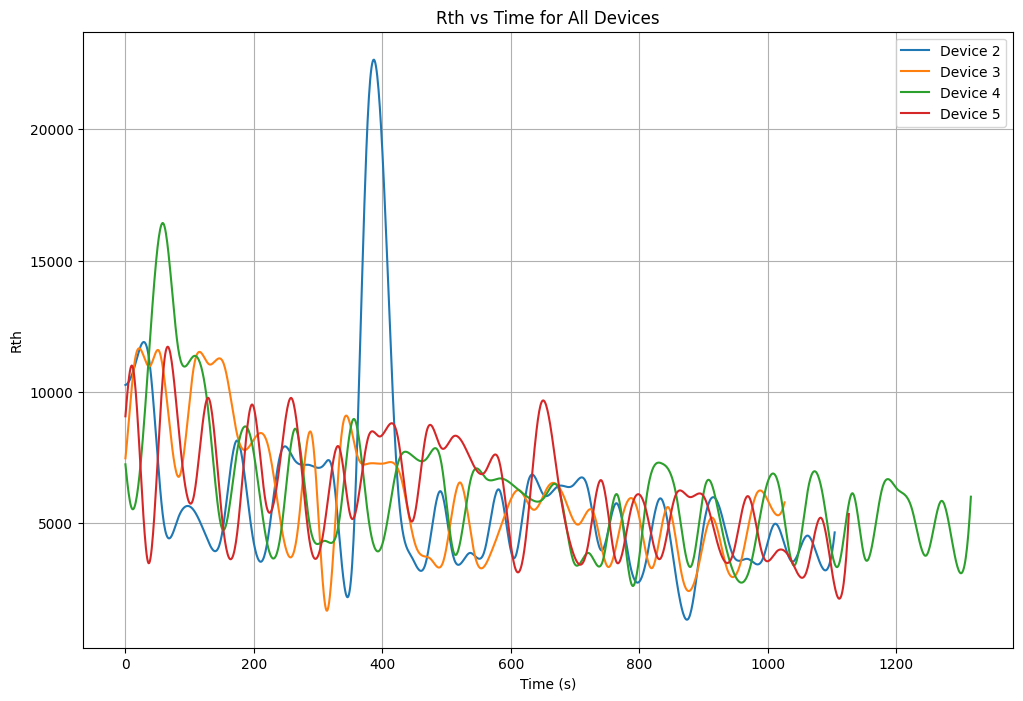

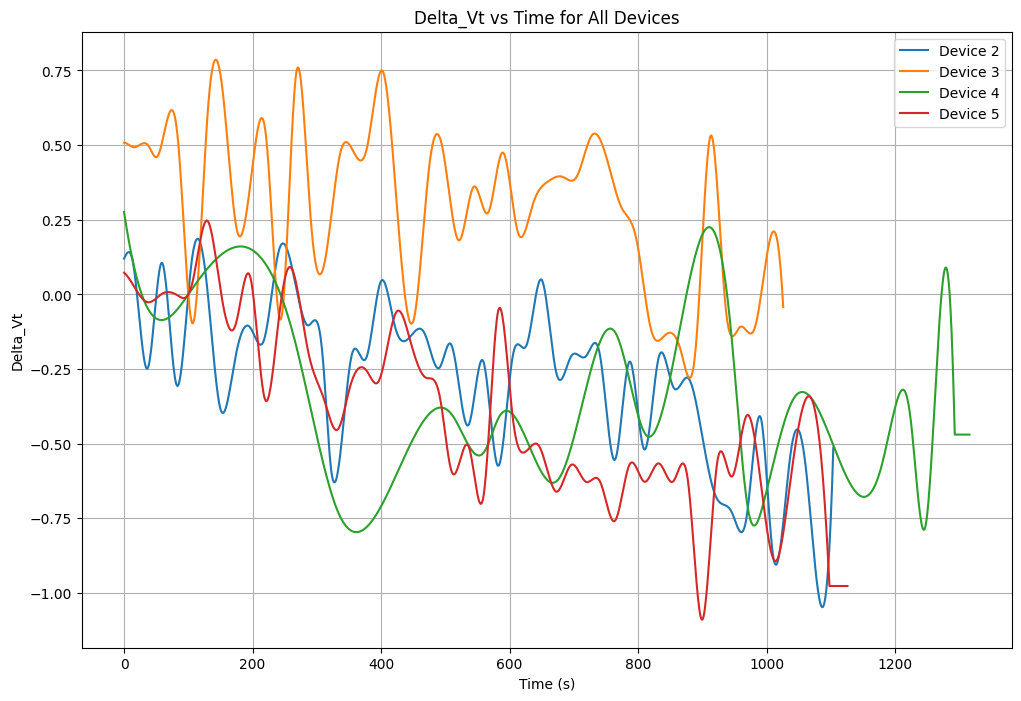

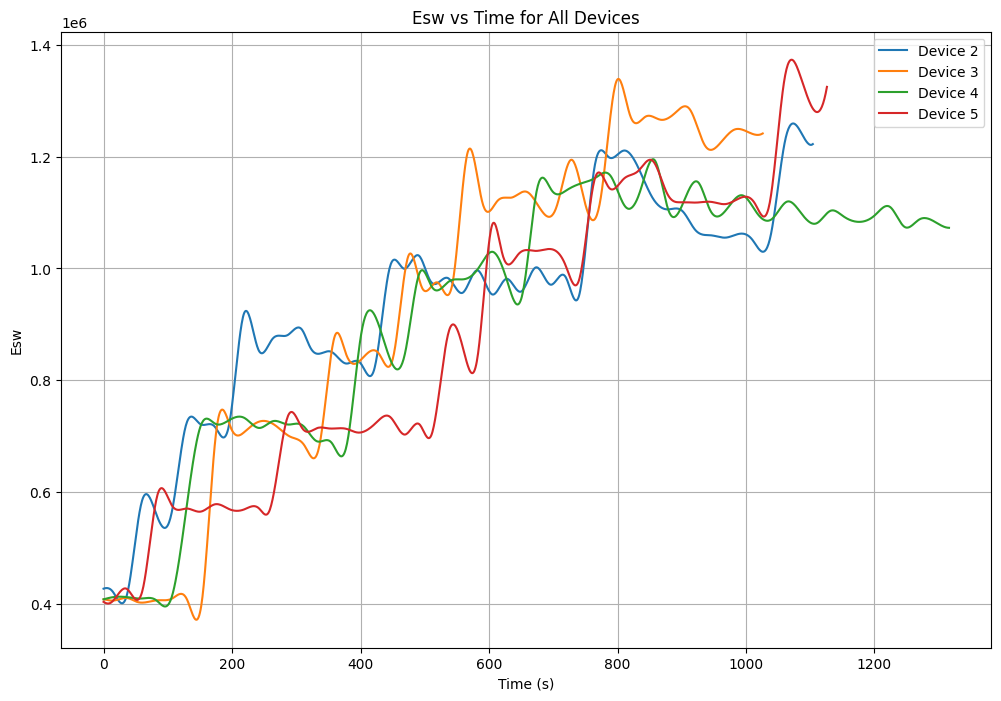

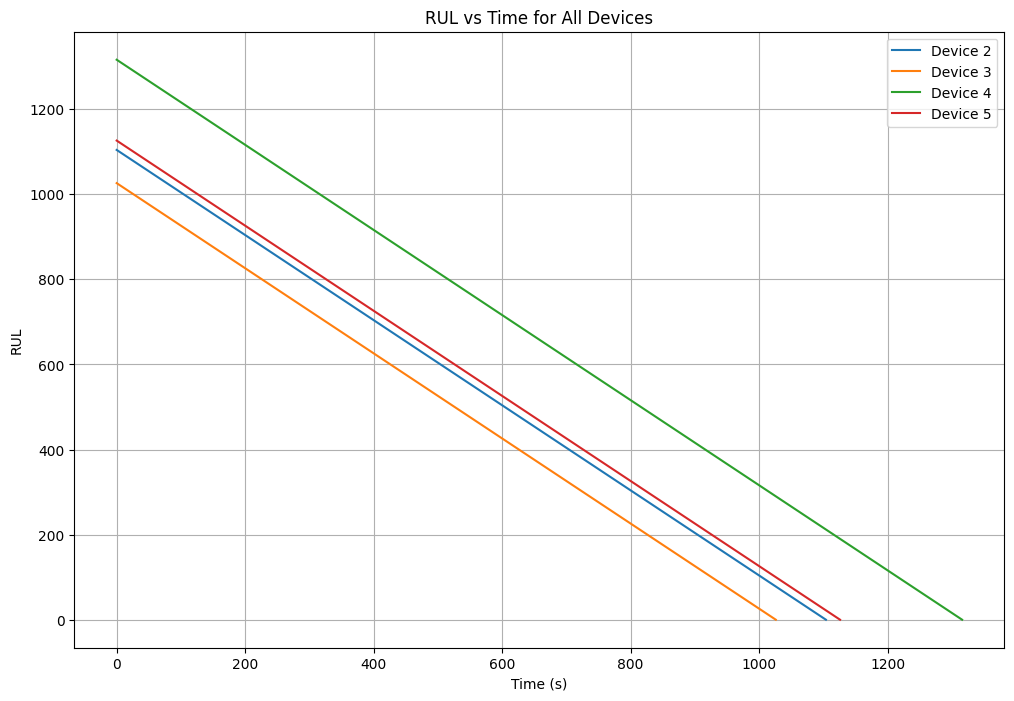

In [53]:
# Plot all features for each device
devices = [device_2_data, device_3_data, device_4_data, device_5_data]
device_names = ["Device 2", "Device 3", "Device 4", "Device 5"]

features = ['Rth', 'Delta_Vt', 'Esw', 'RUL']

# Plot eacah feature in a separate subplot for each device
for feature in features:
    plt.figure(figsize=(12, 8))
    for device, name in zip(devices, device_names):
        plt.plot(device['time'], device[feature], label=name)
    plt.title(f"{feature} vs Time for All Devices")
    plt.xlabel("Time (s)")
    plt.ylabel(feature)
    plt.legend()
    plt.grid()
    plt.show()


In [66]:
# Model definitions

rul_scale = 2000.0  # To normalize the RUL values to be bewteen 0 and 1, which Claude recommended might be a good idea...

class RULModel(torch.nn.Module):
    """ Contains a CNN fed by Esw, an LSTM fed by Rth and Vt, and a cross attention layer that combines the CNN and LSTM outputs to predict RUL. """
    def __init__(self, input_size: int, hidden_size: int, num_layers: int):
        super(RULModel, self).__init__()
        self.cnnconv1=    torch.nn.Conv1d(in_channels=1, out_channels=hidden_size, kernel_size=7, padding='same', dilation=2)
        self.cnnconv2=    torch.nn.Conv1d(in_channels=1, out_channels=hidden_size, kernel_size=5, padding='same')
        self.cnnrelu =    torch.nn.ReLU()
        self.cnnbn = torch.nn.BatchNorm1d(hidden_size)
        # self.cnnpool =  torch.nn.AdaptiveAvgPool1d(1)
        self.cnnpool =  torch.nn.AvgPool1d(kernel_size=4, stride=4)  # Downsample by a factor of 4 to reduce sequence length for attention
        self.lstm = torch.nn.LSTM(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.attention = torch.nn.MultiheadAttention(embed_dim=hidden_size, num_heads=2, batch_first=True)
        self.fc = torch.nn.Linear(hidden_size, 1)

    def forward(self, esw, rth_vt):
        # CNN branch for Esw
        # esw = esw.permute(0,2,1)  # Add channel dimension; suggested by Gemini
        # esw = esw.unsqueeze(1)  # Add channel dimension
        esw = esw.view(esw.size(0), 1, -1)  # Reshape to (1, 1, seq_len)
        rth_vt = rth_vt.view(rth_vt.size(0), -1, 2)  # Add batch dimension for LSTM

        cnn_out = self.cnnconv1(esw)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnconv2(cnn_out)
        cnn_out = self.cnnrelu(cnn_out)
        cnn_out = self.cnnbn(cnn_out)
        cnn_out = self.cnnpool(cnn_out).transpose(1,2) 

        # LSTM branch for Rth and Vt
        lstm_out, _ = self.lstm(rth_vt)
        
        # Cross attention between CNN and LSTM outputs
        attn_output, _ = self.attention(cnn_out, lstm_out,  lstm_out)
        
        # Final RUL prediction
        # rul_pred = self.fc(attn_output[:, 0, :])  # Want a scalar
        rul_pred = self.fc(cnn_out)  # Want a scalar
        # rul_pred = self.fc(lstm_out[:, 0, :])  # Want a scalar
        
        return rul_pred


In [64]:
# Try to train the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def predict_rul(model, data, window_size=50):
    model.eval()
    rul_preds = []
    with torch.no_grad():
        for start_idx in range(0, len(data) - window_size, window_size):
            data_window = data.iloc[start_idx:start_idx+window_size]

            esw = torch.tensor(data_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(data_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            rul_pred = model(esw, rth_vt)
            rul_preds.append(rul_pred.item())
    
    return rul_preds

def train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.001, batch_size=100):
    mseloss = torch.nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    allloss = []

    # move things to the device:
    model.to(device)
    mseloss.to(device)
    # data_dev = data_dev.to(device)
    # data_train = [d.to(device) for d in data_train]

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for device_data in data_train:
            # window_size = np.random.randint(256, 2048)  # Random window size
            # Claude helped with trasforming my code from individual runs to batching, which speeds things up tremendously!
            # i=0
            # esw_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size]['Esw'].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size)
            
            # rth_vt_batch = torch.stack([
            #     torch.tensor(device_data.iloc[i:i+window_size][['Rth', 'Delta_Vt']].values, dtype=torch.float32)
            #     for window_size in range(8, len(device_data))
            # ]).to(device)  # (batch_size, window_size, 2)
            
            # rul_batch = torch.tensor([
            #     device_data.iloc[i+window_size-1]['RUL'] / rul_scale
            #     for window_size in range(8, len(device_data))
            # ], dtype=torch.float32).to(device)  # (batch_size,)

            esw = torch.tensor([device_data['Esw'].values], dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt = torch.tensor(device_data[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # Get rul at the end of the window
            # rul = torch.tensor(device_data_window.iloc[-1]['RUL'], dtype=torch.float32).to(device) / rul_scale  # Normalize RUL to be between 0 and 1

            optimizer.zero_grad()
            # rul_pred = model(esw_batch, rth_vt_batch)
    
            # Calculate coffin manson estimate
            # delta_T_batch = torch.tensor([
            #     device_data.iloc[i:i+window_size]['time_domain_internalTemperature'].max() -
            #     device_data.iloc[i:i+window_size]['time_domain_internalTemperature'].min()
            #     for window_size in range(8, len(device_data))
            # ], dtype=torch.float32).to(device)
            # Nf_batch = 0.05 * (delta_T_batch ** -2.5)

            rul_pred = model(esw, rth_vt)
            rul_true = torch.tensor(device_data['RUL'].values / rul_scale, dtype=torch.float32).to(device)  # (N,)
                
            loss = 0.7 * mseloss(rul_pred.squeeze(), rul_true) + 0.3 * torch.abs(rul_pred.squeeze() - rul_true).mean()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Evaluate on development set
        model.eval()
        dev_loss = 0.0
        with torch.no_grad():
            data_dev_window = data_dev

            esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
            rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

            # esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).to(device)
            # rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Delta_Vt']].values, dtype=torch.float32).to(device)
            rul_dev = torch.tensor(data_dev_window.iloc[-1]['RUL'], dtype=torch.float32).to(device) / rul_scale  # Normalize RUL to be between 0 and 1
            rul_pred_dev = model(esw_dev, rth_vt_dev)

            dev_loss += mseloss(rul_pred_dev.squeeze(), rul_dev).item()

        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss/len(data_train):.4f}, Dev Loss: {dev_loss/len(data_dev):.4f}")
        allloss += [(train_loss/len(data_train), dev_loss/len(data_dev))]

    return allloss


In [67]:
# Train the model...

model = RULModel(input_size=2, hidden_size=32, num_layers=2)
loss = train_model(model, data_train, data_dev, num_epochs=100, learning_rate=0.0001, batch_size=128)

RuntimeError: Given groups=1, weight of size [32, 1, 5], expected input[1, 32, 1027] to have 1 channels, but got 32 channels instead

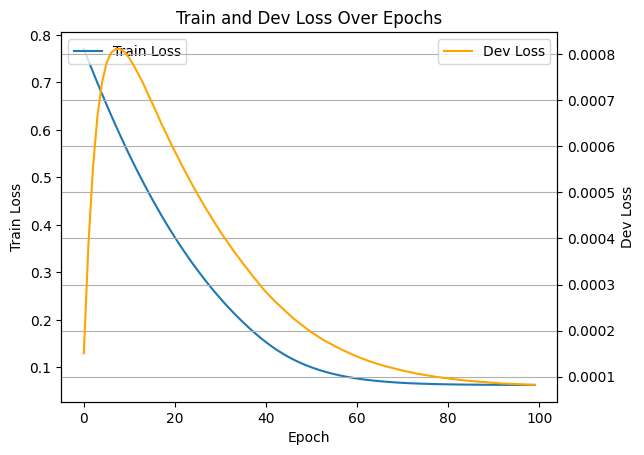

In [57]:

# plot train, dev loss on separate y-axes:
plt.title("Train and Dev Loss Over Epochs")
plt.xlabel("Epoch")
plt.plot([l[0] for l in loss], label="Train Loss")
plt.ylabel("Train Loss")
plt.legend(loc="upper left")
plt.twinx()
plt.plot([l[1] for l in loss], label="Dev Loss", color='orange')
plt.ylabel("Dev Loss")
plt.legend(loc="upper right")
plt.grid()
plt.show()

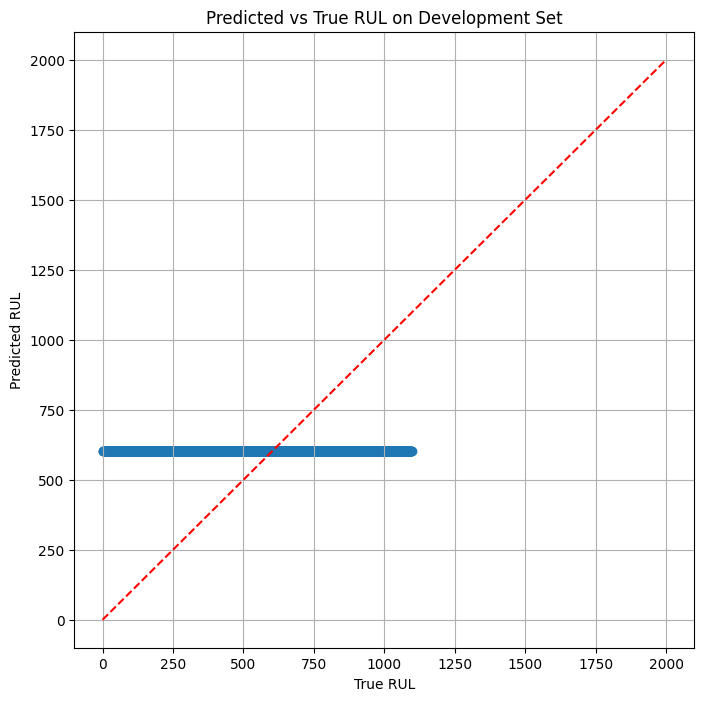

In [59]:
# Plot estimated RUL vs true RUL for the development set

data_pred = []

model.eval()
# window_size = 1024
with torch.no_grad():
    # go through windows sequentially
    # for start_idx in range(0, len(data_dev) - window_size):
    for window_size in range(8, len(data_dev)):
        start_idx = 0
        data_dev_window = data_dev.iloc[start_idx:start_idx+window_size]
        esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
        rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

        # esw_dev = torch.tensor(data_dev_window['Esw'].values, dtype=torch.float32).to(device)
        # rth_vt_dev = torch.tensor(data_dev_window[['Rth', 'Vt']].values, dtype=torch.float32).to(device)
        rul_dev = torch.tensor(data_dev_window.iloc[-1]['RUL'], dtype=torch.float32).to(device) / rul_scale  # Normalize RUL to be between 0 and 1
        rul_pred_dev = model(esw_dev, rth_vt_dev)
        data_pred += [(rul_dev.item() * rul_scale, rul_pred_dev.item() * rul_scale)]

# Plot
plt.figure(figsize=(8, 8))
plt.scatter([d[0] for d in data_pred], [d[1] for d in data_pred])
plt.plot([0, 2000], [0, 2000], 'r--')  # Line y=x for reference
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL on Development Set")
plt.grid()
plt.show()

ValueError: x and y must have same first dimension, but have shapes (1205,) and (1155,)

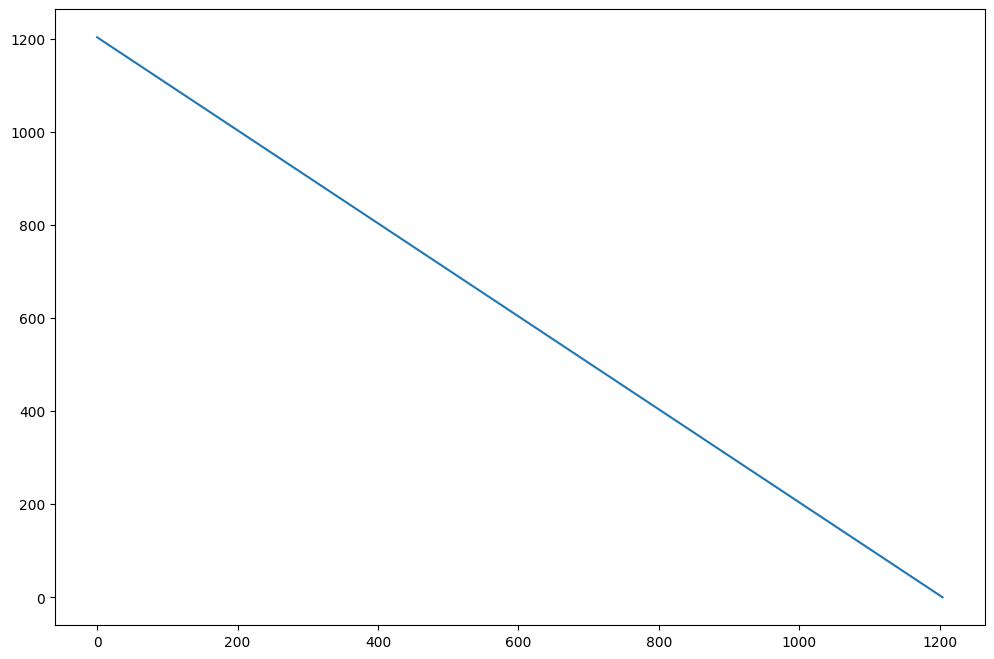

In [46]:
# Plot estimated RUL vs True RUL for the development set

true_rul = data_dev['RUL'].values

with torch.no_grad():
    esw_dev = torch.tensor(data_dev['Esw'].values, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)
    rth_vt_dev = torch.tensor(data_dev[['Rth', 'Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

    for timestep in range(len(data_dev) - 50):
        esw_window = esw_dev[:, timestep:timestep+50, :]
        rth_vt_window = rth_vt_dev[:, timestep:timestep+50, :]
        if esw_window.shape[1] < 50:  # If we don't have enough data for a full window, skip
            continue
        rul_pred_dev = model(esw_window, rth_vt_window)
        if timestep == 0:
            pred_rul = rul_pred_dev.cpu().numpy().flatten()
        else:
            pred_rul = np.append(pred_rul, rul_pred_dev.cpu().numpy().flatten())

plt.figure(figsize=(12, 8))
plt.plot(data_dev['time'], true_rul, label="True RUL")
plt.plot(data_dev['time'], pred_rul, label="Predicted RUL")
plt.title("True vs Predicted RUL on Development Set")
plt.xlabel("Time (s)")
plt.ylabel("RUL")
plt.legend()
plt.grid()
plt.show()

In [47]:
model.eval()
with torch.no_grad():
    w1 = data_dev.iloc[0:window_size]
    esw1 = torch.tensor(w1['Esw'].values, dtype=torch.float32).unsqueeze(0).to(device)
    rth1 = torch.tensor(w1[['Rth', 'Delta_Vt']].values, dtype=torch.float32).unsqueeze(0).to(device)

    # Trace through each stage
    esw_view = esw1.view(esw1.size(0), 1, -1)
    print("esw_view shape:", esw_view.shape)
    
    cnn_out = model.cnnconv1(esw_view)
    print("after conv:", cnn_out.shape, "mean:", cnn_out.mean().item())
    
    cnn_out = model.cnnrelu(cnn_out)
    print("after relu:", cnn_out.mean().item())
    
    cnn_out = model.cnnpool(cnn_out).transpose(1, 2)
    print("after pool:", cnn_out.shape, "mean:", cnn_out.mean().item())

    rth_view = rth1.view(rth1.size(0), -1, 2)
    lstm_out, _ = model.lstm(rth_view)
    print("lstm_out shape:", lstm_out.shape, "mean:", lstm_out.mean().item())

    attn_output, attn_weights = model.attention(cnn_out, lstm_out, lstm_out)
    print("attn_output shape:", attn_output.shape, "mean:", attn_output.mean().item())
    print("attn_weights:", attn_weights)

esw_view shape: torch.Size([1, 1, 1024])
after conv: torch.Size([1, 32, 1022]) mean: -131983.328125
after relu: 192438.203125
after pool: torch.Size([1, 255, 32]) mean: 192407.296875
lstm_out shape: torch.Size([1, 1024, 32]) mean: -0.08731112629175186
attn_output shape: torch.Size([1, 255, 32]) mean: -0.01996128261089325
attn_weights: tensor([[[1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.],
         [1., 0., 0.,  ..., 0., 0., 0.]]], device='cuda:0')
